# Structural Vulnerability Analysis on MDOF System using Incremental Dynamic Analysis

## Introduction

This Jupyter Notebook provides a structured workflow for performing Incremental Dynamic Analysis (IDA) on multi-degree-of-freedom (MDOF) structural models. Unlike static or traditional dynamic methods, IDA involves subjecting a structural model to one or more ground motion records, each scaled to multiple levels of intensity. This produces a curve of structural response (e.g., maximum interstorey drift) versus intensity level (e.g., spectral acceleration), providing a comprehensive view of the building's performance from elasticity through to global dynamic instability or collapse.

The main goals of this notebook:

1. **Compile and construct MDOF Models in OpenSees**: Define and assemble MDOF models by specifying essential structural properties, including mass, heights and nonlinear response characteristics at each degree of freedom

2. **Perform Incremental Dynamic Analysis (IDA)**: Systematically scale ground motion records using a "Hunt and Fill" algorithm. This approach rapidly identifies the collapse capacity of the system and then refines the intensity steps to capture the nonlinear transition points and the "flatline" region where the structure reaches dynamic instability.

3. **Fragility Analysis**: Postprocess the IDA curves to determine the capacity of the structure at various limit states. By analyzing the distribution of intensities that trigger specific drift thresholds, we construct fragility functions that describe the probability of exceeding a damage state as a function of ground-shaking intensity.

4. **Vulnerability Analysis**: Integrate these fragility functions with consequence models (i.e., damage-to-loss models) to determine the continuous relationship between a decision variable (such as repair cost ratio) and increasing levels of ground-shaking intensities.

The notebook provides a step-by-step guide, covering each phase from MDOF model creation and scaling-protocol configuration to analysis execution and detailed results extraction. Users should have some familiarity with Python scripting, structural dynamics, computational modeling, and performance-based earthquake engineering (PBEE) to fully benefit from this material.

---

## References

[1] Vamvatsikos, D. and Cornell, C.A. (2002), Incremental dynamic analysis. Earthquake Engng. Struct. Dyn., 31: 491-514. https://doi.org/10.1002/eqe.141

[2] Vamvatsikos, D. and Cornell, C.A. (2004), Applied Incremental Dynamic Analysis. Earthquake Spectra. 2004;20(2):523-553. doi:10.1193/1.1737737

[3] Baker, J.W. (2015), Efficient Analytical Fragility Function Fitting Using Dynamic Structural Analysis. Earthquake Spectra. 2015;31(1):579-599. doi:10.1193/021113EQS025M

## Initialize Libraries ##

In [4]:
import os
import sys
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import the classes necessary for structural analysis
from openquake.vmtk.units         import units              # OQ-VMTK units class
from openquake.vmtk.calibration   import calibrate_model    # OQ-VMTK sdof-to-mdof calibration class
from openquake.vmtk.im_calculator import IMCalculator       # OQ-VMTK intensity measure processor class
from openquake.vmtk.modeller      import modeller           # OQ-VMTK numerical modelling class
from openquake.vmtk.postprocessor import postprocessor      # OQ-VMTK postprocessing class
from openquake.vmtk.plotter       import plotter            # OQ-VMTK plotting class
from openquake.vmtk.utilities     import sorted_alphanumeric, import_from_pkl, export_to_pkl # OQ-VMTK utility class

## Define Plotting Constants for OQ-VMTK Non-Native Plots ##

In [5]:
FONTSIZE_1 = 16
FONTSIZE_2 = 14
FONTSIZE_3 = 12

LINEWIDTH_1= 3
LINEWIDTH_2= 2
LINEWIDTH_3 = 1

RESOLUTION = 500

MARKER_SIZE_1 = 100
MARKER_SIZE_2 = 60
MARKER_SIZE_3 = 10

COLOR = "#399283"

## Define Directories ##

In [6]:
# Define the directory of the ground-motion records
gm_directory  = './in/records'            

# Define the main output directory
ida_directory = './out'  
os.makedirs(ida_directory, exist_ok=True)

## Load FEMA P-695 Acceleration Time-Histories and Process Intensity Measures ## 

{'PGA': [], 'PGV': [], 'PGD': [], 'SA(0.3s)': [], 'SA(0.6s)': [], 'SA(1.0s)': [], 'AvgSA': [], 'AvgSA(0.3s)': [], 'AvgSA(0.6s)': [], 'AvgSA(1.0s)': [], 'AI': [], 'D595': []}


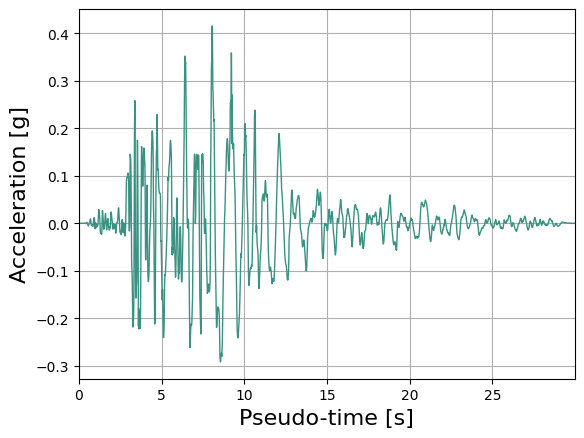

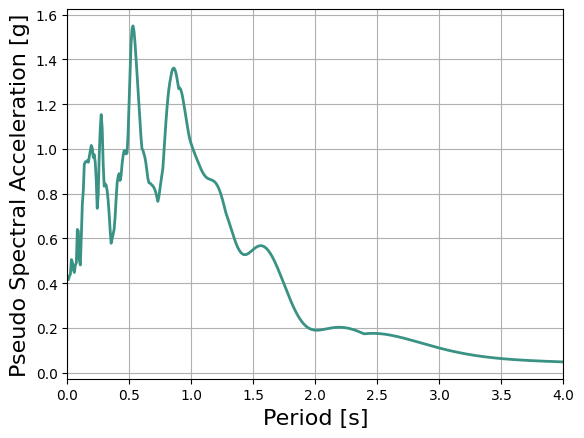

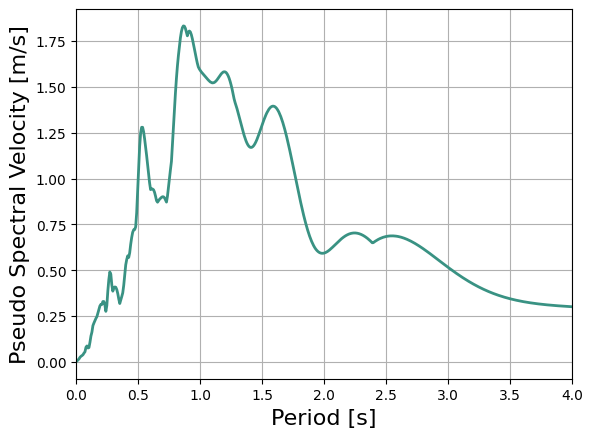

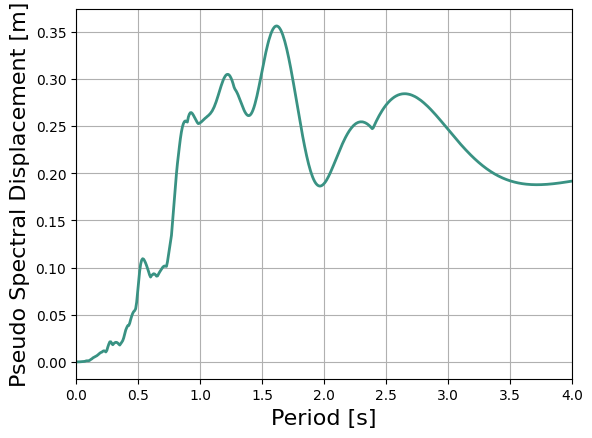

Peak Ground Acceleration (PGA): 0.4158 g
Peak Ground Velocity (PGV): 0.5895 m/s
Peak Ground Displacement (PGD): 0.1314 m
Arias Intensity (AI): 0.0319 m/s
Cumulative Absolute Velocity (CAV): 1.4551 m/s
Significant Duration (5%-95% AI): 9.2100 s
Spectral Acceleration (SA at 0.3s): 0.8376 g
Spectral Acceleration (SA at 0.6s): 1.0090 g
Spectral Acceleration (SA at 1.0s): 1.0193 g
Average Spectral Acceleration (AvgSA at 0.3s): 0.7806 g
Average Spectral Acceleration (AvgSA at 0.6s): 0.9571 g
Average Spectral Acceleration (AvgSA at 1.0s): 0.8485 g
Average Spectral Acceleration (AvgSA at [0.01-1.0]): 0.9412 g


In [7]:
# The set of ground-motion records utilized correspond to the acceleration time-histories of FEMA P695 Far Field Set

# Input the intensity measure types required for processing
IMT = ['PGA','PGV','PGD','SA(0.3s)','SA(0.6s)','SA(1.0s)','AvgSA','AvgSA(0.3s)','AvgSA(0.6s)','AvgSA(1.0s)','AI','D595']

# Fetch the acceleration files
gmrs = sorted_alphanumeric(os.listdir(os.path.join(gm_directory, 'acc')))

# Load the time-step file
dts = pd.read_csv(os.path.join(gm_directory, 'FEMA_P695_unscaled_dts.txt'),sep=" ", header=None).values

# Load the duration file
durs = pd.read_csv(os.path.join(gm_directory, 'FEMA_P695_unscaled_durs.txt'),sep=" ", header=None).values

# Initialise the storage dictionary and name the "keys" in accordance with the defined IMT
imls = {}
for i, current_imt in enumerate(IMT):    
    imls[current_imt] = []

# Visualise the dictionary
print(imls)

# Loop over the files
for i in range(len(gmrs)):
    
    ### Load the acceleration time-histories and the corresponding time-step and durations
    current_acc = pd.read_csv(os.path.join(gm_directory,'acc',f'gm_{i+1}.txt'),sep=" ", header=None).to_numpy().flatten()
    dt_gm       = float(dts[i].item())
    dur_gm      = float(durs[i].item())

    ### Create the pseudo time-step array
    # Compute number of points safely
    num_points = int(dur_gm / dt_gm)
    
    # Generate pseudo time steps and save them unto "dts" folder
    current_dts = np.linspace(dt_gm, dur_gm, num_points) 
    os.makedirs(os.path.join(gm_directory, 'dts'),exist_ok=True)
    save_path = os.path.join(gm_directory, 'dts', f"dt_{i+1}.txt")
    np.savetxt(save_path, current_dts)
    
    ### Plot the time history only for the first ground-motion record
    if i==0:
        plt.plot(current_dts, current_acc, color = COLOR, lw=LINEWIDTH_3)
        plt.xlabel('Pseudo-time [s]', fontsize= FONTSIZE_1)
        plt.ylabel('Acceleration [g]', fontsize = FONTSIZE_1)
        plt.grid(visible=True, which='major')
        plt.grid(visible=True, which='minor')
        plt.xlim([0.00, np.max(current_dts)])
        plt.show()

    ### Initialise the Intensity Measure Calculator class
    # The class "IMCalculator" is initialised using the acceleration array and the time-step scalar value
    im_calculator = IMCalculator(current_acc,dt_gm) 

    ### Calculate amplitude-based intensity measures: peak ground acceleration, peak ground velocity, peak ground displacement 
    pga, pgv, pgd = im_calculator.get_amplitude_ims()
    
    ### Calculate duration-based intensity measures: arias intensity, cumulative absolute velocity, significant duration d595
    ai, cav, t595 = im_calculator.get_duration_ims()
     
    ### Calculate and plot the acceleration, velocity and displacement spectra 
    periods, sd, sv, sa = im_calculator.get_spectrum()

    ### Plot the spectra only for the first ground-motion record
    if i==0:

        # Acceleration Spectrum
        plt.plot(periods, sa, color = COLOR, lw=LINEWIDTH_2)
        plt.xlabel('Period [s]', fontsize= FONTSIZE_1)
        plt.ylabel('Pseudo Spectral Acceleration [g]', fontsize = FONTSIZE_1)
        plt.grid(visible=True, which='major')
        plt.grid(visible=True, which='minor')
        plt.xlim([0.00, np.max(periods)])
        plt.show()

        # Velocity Spectrum 
        plt.plot(periods, sv, color = COLOR, lw=LINEWIDTH_2)
        plt.xlabel('Period [s]', fontsize= FONTSIZE_1)
        plt.ylabel('Pseudo Spectral Velocity [m/s]', fontsize = FONTSIZE_1)
        plt.grid(visible=True, which='major')
        plt.grid(visible=True, which='minor')
        plt.xlim([0.00, np.max(periods)])
        plt.show()

        # Displacement Spectrum 
        plt.plot(periods, sd, color = COLOR, lw=LINEWIDTH_2)
        plt.xlabel('Period [s]', fontsize= FONTSIZE_1)
        plt.ylabel('Pseudo Spectral Displacement [m]', fontsize = FONTSIZE_1)
        plt.grid(visible=True, which='major')
        plt.grid(visible=True, which='minor')
        plt.xlim([0.00, np.max(periods)])
        plt.show()

    ### Calculate the spectral acceleration values at distinct periods (e.g., 0.3, 0.6 and 1.0s)
    sa03 = im_calculator.get_sa(0.3)
    sa06 = im_calculator.get_sa(0.6)
    sa10 = im_calculator.get_sa(1.0)

    ### Calculate the average spectral acceleration values at distinct periods (e.g., 0.3, 0.6 and 1.0s) 
    ### with an auto-defined range of 0.2T and 1.5T
    avgsa03 = im_calculator.get_saavg(0.3)
    avgsa06 = im_calculator.get_saavg(0.6)
    avgsa10 = im_calculator.get_saavg(1.0)

    ### Calculate the average spectral acceleration values at distinct periods (e.g., 0.3, 0.6 and 1.0s)
    ### with a user defined range 
    periods_list = np.linspace(0.1,1.0,10)
    avgsa = im_calculator.get_saavg_user_defined(periods_list)

    ### Print outputs only for first record
    if i==0:
        print(f"Peak Ground Acceleration (PGA): {pga:.4f} g")
        print(f"Peak Ground Velocity (PGV): {pgv:.4f} m/s")
        print(f"Peak Ground Displacement (PGD): {pgd:.4f} m")
    
        print(f"Arias Intensity (AI): {ai:.4f} m/s")
        print(f"Cumulative Absolute Velocity (CAV): {cav:.4f} m/s")
        print(f"Significant Duration (5%-95% AI): {t595:.4f} s")
       
        print(f"Spectral Acceleration (SA at 0.3s): {sa03:.4f} g")
        print(f"Spectral Acceleration (SA at 0.6s): {sa06:.4f} g")
        print(f"Spectral Acceleration (SA at 1.0s): {sa10:.4f} g")
    
        print(f"Average Spectral Acceleration (AvgSA at 0.3s): {avgsa03:.4f} g")
        print(f"Average Spectral Acceleration (AvgSA at 0.6s): {avgsa06:.4f} g")
        print(f"Average Spectral Acceleration (AvgSA at 1.0s): {avgsa10:.4f} g")
        print(f"Average Spectral Acceleration (AvgSA at [0.01-1.0]): {avgsa:.4f} g")

    ### Store the intensity measures in dictionary
    for j, current_imt in enumerate(IMT):

        if current_imt == 'PGA':
            imls[current_imt].append(pga) 
        elif current_imt == 'PGV':
            imls[current_imt].append(pgv) 
        elif current_imt == 'PGD':
            imls[current_imt].append(pgd)         
        elif current_imt == 'SA(0.3s)':
            imls[current_imt].append(sa03) 
        elif current_imt == 'SA(0.6s)':
            imls[current_imt].append(sa06) 
        elif current_imt == 'SA(1.0s)':
            imls[current_imt].append(sa10) 
        elif current_imt == 'AvgSA':
            imls[current_imt].append(avgsa)                                               
        elif current_imt == 'AvgSA(0.3s)':
            imls[current_imt].append(avgsa03) 
        elif current_imt == 'AvgSA(0.6s)':
            imls[current_imt].append(avgsa06) 
        elif current_imt == 'AvgSA(1.0s)':
            imls[current_imt].append(avgsa10)
        elif current_imt == 'AI':
            imls[current_imt].append(ai) 
        elif current_imt == 'AI':
            imls[current_imt].append(cav) 
        elif current_imt == 'D595':
            imls[current_imt].append(t595) 

# Export to pickle format 
export_to_pkl(os.path.join(gm_directory,'imls_femap695.pkl'), imls)

## Calibrate and Compile an MDOF Model based on SDOF Capacity ##

In [8]:
# Number of storeys
number_storeys = 2

# Relative floor heights list
storey_heights = [2.80, 2.80]

# First-mode based participation factor
gamma = 1.33

# SDOF capacity (First row are Spectral Displacement [m] values - Second row are Spectral Acceleration [g] values)
sdof_capacity = np.array([[0.00060789, 0.00486316, 0.02420000, 0.04353684], 
                          [0.10315200, 0.20630401, 0.12378241, 0.12502023]]).T
# Frame flag
isFrame = False

# Soft-storey mechanism flag
isSOS = False

# Degradation flag 
mdof_degradation = True

# Inherent damping 
mdof_damping = 0.05

# Calibrate the model
floor_masses, storey_drifts, storey_forces, mdof_phi, meta = calibrate_model(number_storeys,
                                                                             sdof_capacity,
                                                                             isSOS=isSOS,
                                                                             storey_heights=storey_heights,
                                                                             verbose=False)

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Stopped because of load factor below zero


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


## Setting Up, Running and Exporting Incremental Dynamic Analysis ##

In the next code snippet, incremental dynamic analyses are performed on the pre-calibrated stick model using a suite of recorded ground-motion time histories from the FEMA P695 Far Field Record Set.

For each ground-motion record, the MDOF model is compiled, gravity-loaded, and subjected to modal analysis to extract its dynamic properties. The ground motion is then applied through NLTHA using consistent time-stepping, appropriate unit scaling, and specified damping.

The analysis extracts key engineering demand parameters (EDPs), including peak storey drifts, peak floor accelerations, and peak floor displacements along the building height. Maximum response values, together with their associated directions and locations, are also recorded. Numerical convergence is monitored through a convergence index.

All response quantities are stored for each record and aggregated into a structured dataset, which is exported for subsequent fragility development, and vulnerability analysis.

============== IDA Analysing: 1 out of 44 ==================


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


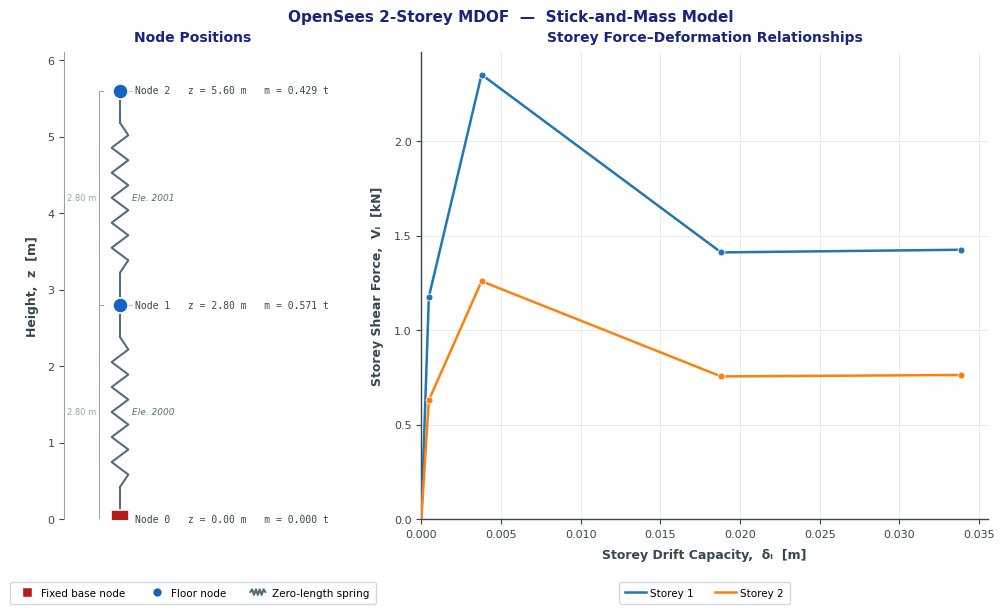

 -- Run 1/30 | SF: 0.100


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
 -- Run 2/30 | SF: 0.200


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
 -- Run 3/30 | SF: 0.400


...

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Collapse/Target Reached! Capping drift at 0.1
Hunt terminated: Limit reached at SF = 1.6
 -- Run 6/30 | SF: 0.600


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
 -- Run 7/30 | SF: 0.500


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
ANALYSIS COMPLETED!


In [11]:
# Initialise MDOF storage lists
# Note: Each element in these lists will now contain the IDA curve data for that record
conv_index_list = []                
peak_disp_list  = []                
peak_drift_list = []                
peak_accel_list = []                
max_peak_drift_list = []            
max_peak_drift_dir_list = []        
max_peak_drift_loc_list = []        
max_peak_accel_list = []            
max_peak_accel_dir_list = []        
max_peak_accel_loc_list = []        

# Loop over ground-motion records, compile MDOF model and run NLTHA
gmrs = sorted_alphanumeric(os.listdir(os.path.join(gm_directory,'acc')))                         # Sort the ground-motion records alphanumerically
dts  = sorted_alphanumeric(os.listdir(os.path.join(gm_directory,'dts')))                         # Sort the ground-motion time-step files alphanumerically

# Initialize the SF Matrix: Rows = Records, Cols = Run Number
max_runs_per_record = 30
sf_matrix = np.full((len(gmrs), max_runs_per_record), np.nan)

# Loop over ground-motion records
for i in range(len(gmrs)):
    print('================================================================')
    print('============== IDA Analysing: {:d} out of {:d} =================='.format(i+1, len(gmrs)))
    print('================================================================')

    # Initialise the modeller class and compile the MDOF model 
    model = modeller(number_storeys, 
                     storey_heights, 
                     floor_masses,
                     storey_drifts, 
                     storey_forces*units.g, 
                     mdof_degradation)
    model.compile_model()

    # Plot the model only for the first ground-motion record
    if i == 0:
        model.plot_model()        

    # Do gravity analysis for system equilibrium
    model.do_gravity_analysis()

    # Do modal analysis
    num_modes = 1 if number_storeys == 1 else 3
    T, phi = model.do_modal_analysis(num_modes=num_modes, plot_modes=False)

    # Define ground motion objects
    fnames = [os.path.join(gm_directory, 'acc', f'{gmrs[i]}')]
    fdts   = os.path.join(gm_directory, 'dts', f'{dts[i]}')

    dt_df    = pd.read_csv(fdts, sep=" ", header=None)
    dt_gm    = dt_df.iloc[1,0] - dt_df.iloc[0,0]
    t_max    = dt_df.iloc[-1,0]
    dt_ansys = dt_gm # Set the analysis time-step equal to the ground-motion time-step

    # Run Incremental Dynamic Analysis
    # This calls the dedidacted "do_incremental_analysis" method from the modeller class 
    # which uses Hunt-Trace-Fill and record_ida_results is a dict: {sf: {all_outputs}}
    record_ida_results, ordered_sfs = model.do_incremental_dynamic_analysis(fnames, 
                                                                            dt_gm, 
                                                                            t_max, 
                                                                            dt_ansys,                                                                   
                                                                            target_drift=0.0135*1.5,
                                                                            initial_sf=0.1,
                                                                            hunt_step=2.0,
                                                                            max_fill_gap=0.2,
                                                                            max_runs = max_runs_per_record,
                                                                            xi=0.05)

    # Fill the matrix for the current record (row i)
    # We fill only up to the number of runs actually performed
    sf_matrix[i, :len(ordered_sfs)] = ordered_sfs
    
    ### Store the analysis results
    # We extract the components for each SF run for this record
    sfs_sorted = sorted(record_ida_results.keys())
    
    # We append the whole IDA "curve" data for this record into your storage lists
    conv_index_list.append({sf: record_ida_results[sf]['conv_index'] for sf in sfs_sorted})
    peak_drift_list.append({sf: record_ida_results[sf]['peak_drift'] for sf in sfs_sorted})
    peak_accel_list.append({sf: record_ida_results[sf]['peak_accel'] for sf in sfs_sorted})
    peak_disp_list.append({sf: record_ida_results[sf]['peak_disp'] for sf in sfs_sorted})
    
    max_peak_drift_list.append({sf: record_ida_results[sf]['max_peak_drift'] for sf in sfs_sorted})
    max_peak_drift_dir_list.append({sf: record_ida_results[sf]['max_peak_drift_dir'] for sf in sfs_sorted})
    max_peak_drift_loc_list.append({sf: record_ida_results[sf]['max_peak_drift_loc'] for sf in sfs_sorted})
    
    max_peak_accel_list.append({sf: record_ida_results[sf]['max_peak_accel'] for sf in sfs_sorted})
    max_peak_accel_dir_list.append({sf: record_ida_results[sf]['max_peak_accel_dir'] for sf in sfs_sorted})
    max_peak_accel_loc_list.append({sf: record_ida_results[sf]['max_peak_accel_loc'] for sf in sfs_sorted})

# Final storage and export (same as your original logic)
ansys_dict = {}
labels = ['T','conv_index_list', 'peak_drift_list','peak_accel_list',
          'max_peak_drift_list', 'max_peak_drift_dir_list', 
          'max_peak_drift_loc_list','max_peak_accel_list',
          'max_peak_accel_dir_list','max_peak_accel_loc_list',
          'peak_disp_list']

for label in labels:
    if label == 'T':
        ansys_dict[label] = T
    else:
        ansys_dict[label] = vars()[label]

# Save the scaling factor matrix to your results dictionary
ansys_dict['sf_matrix'] = sf_matrix

# Export the IDA results to a pickle file
export_to_pkl(os.path.join(ida_directory, 'ida_ansys_out.pkl'), ansys_dict)

print('ANALYSIS COMPLETED!')

## Calculate Scaled Ground Motion Records Intensity Measure ##

In [12]:
# Assuming 'imls' contains the unscaled values from your loop 
# and 'sf_matrix' is the (n_gmrs x max_runs_per_record) matrix from your IDA

n_gmrs = len(gmrs)

# Storage for the expanded IMs
expanded_imls = {}

# Loop over intensity measure types
for current_imt in IMT:
    
    # Initialize a matrix of NaNs for each IMT
    # Size: (Number of Records) x (Number of Runs)
    expanded_imls[current_imt] = np.full((n_gmrs, max_runs_per_record), np.nan)

    # Loop over ground motion records
    for i in range(n_gmrs):

        # Fetch the unscaled IM value
        unscaled_val = imls[current_imt][i]

        # Fetch the row of scaling factors determined by IDA (1xn_runs) and associated with the current record
        sfs = sf_matrix[i, :] # The row of scaling factors for this GM
        
        # Apply scaling logic based on the nature of the IM
        # Linear scaling: IM_scaled = SF * IM_unscaled for amplitude-based IMs
        if current_imt in ['PGA', 'PGV', 'PGD', 'SA(0.3s)', 'SA(0.6s)', 'SA(1.0s)','AvgSA', 'AvgSA(0.3s)', 'AvgSA(0.6s)', 'AvgSA(1.0s)']:
            expanded_imls[current_imt][i, :] = sfs * unscaled_val

        # Quadratic scaling: AI_scaled = SF^2 * AI_unscaled for Arias Intensity
        elif current_imt == 'AI':
            expanded_imls[current_imt][i, :] = (sfs**2) * unscaled_val

        # Duration is scale-invariant: IM_scaled = IM_unscaled
        # We only fill columns where a run was actually performed (sf is not NaN)
        elif current_imt == 'D595':
            mask = ~np.isnan(sfs)
            expanded_imls[current_imt][i, mask] = unscaled_val

# Export the expanded dictionary
export_to_pkl(os.path.join(gm_directory, 'imls_femap695_sf.pkl'), expanded_imls)

## Post-Process Incremental Dynamic Analysis Results: Fragility Functions ##

Incremental Dynamic Analysis (IDA) [1,2] is a computational method used in structural engineering to perform a comprehensive seismic performance evaluation. Unlike Cloud Analysis, which uses unscaled records, IDA involves subjecting a structural model to a suite of ground motion records, each systematically scaled to increasing levels of intensity. This process continues until the structure reaches a specified limit state or global dynamic instability, often referred to as "collapse."

The primary advantage of IDA is that it provides a continuous picture of structural behavior, from the initial elastic response through the onset of yielding, and finally to the "flatline" where a small increase in seismic intensity results in an infinite increase in structural demand. By aggregating these curves, engineers can determine the median capacity and the record-to-record variability, allowing for a highly accurate derivation of fragility curves for multiple damage states.

For a given damage state defined by an Engineering Demand Parameter (EDP) threshold

$$
EDP \ge EDP_{DS}
$$

each IDA curve is interrogated to determine the intensity measure at which the damage state is first exceeded. This produces a set of intensity values

$$
IM_{DS,1}, IM_{DS,2}, \dots, IM_{DS,n}
$$

where $IM_{DS,i}$ is the intensity at which damage state exceedance occurs for the $i$-th ground motion, and $n$ is the number of records analyzed.

$$
\hat{P}(DS \mid IM = x)=
\frac{1}{n}
\sum_{i=1}^{n}
\mathbf{1}(IM_{DS,i} \le x)
$$

where $\mathbf{1}(\cdot)$ is the indicator function.

Plotting these probabilities against $IM$ yields the empirical cumulative distribution function (ECDF) of damage state capacity.

### Fragility Function Derivation using Method of Moments (MoM) ###

#### Step 1: The Lognormal Distribution Assumption #### 

Following common practice in performance-based earthquake engineering, the intensity associated with damage state exceedance is assumed to be lognormally distributed. The fragility function represents the probability of exceeding a damage state ($DS$) conditioned on the intensity measure ($IM$). It is conventionally modeled using a lognormal cumulative distribution function (CDF):$$P(DS \ge ds \mid IM = im) = \Phi \left( \frac{\ln(im / \theta)}{\beta} \right)$$ where: 
* $\theta$ is the median capacity (the intensity level with a 50% probability of exceedance)
* $\beta$ is the logarithmic standard deviation (dispersion) representing record-to-record variability
* $\Phi(\cdot)$ denotes the standard normal cumulative distribution function.


#### Step 2: Method-of-Moments Estimation ####

The fragility function parameters are obtained by taking logarithms of each exceedance intensity and computing their sample mean and standard deviation.


$$
\hat{\mu}_{\ln IM}=
\frac{1}{n}
\sum_{i=1}^{n}
\ln(IM_{DS,i})
$$

Because the mean of $\ln(IM)$ equals the logarithm of the median for a lognormal variable, the median intensity associated with damage state exceedance is

$$
\hat{IM}_{DS}
=
\exp(\hat{\mu}_{\ln IM})
$$

whereas the associated dispersion, corresponding to record-to-record variability, is calculated as such:

$$
\hat{\beta}_{\text{record-to-record}}=
\sqrt{
\frac{1}{n-1}
\sum_{i=1}^{n}
\left[
\ln(IM_{DS,i}) - \hat{\mu}_{\ln IM}
\right]^2
}
$$

where $n$ is the number of ground motions considered.

#### Step 3: Optimization and Total Uncertainty #### 

The total dispersion $\beta_{ds_i}^{\text{total}}$ is then computed by incorporating epistemic uncertainties using the root sum of squares (SRSS):$$\beta_{ds_i}^{\text{total}} = \sqrt{\hat{\beta}_{\text{record-to-record}}^2 + \beta_{\text{building-to-building}}^2 + \beta_{\text{DS}}^2}$$ where: 
* $\hat{\beta}_{\text{record-to-record}}$ is the dispersion derived from the record-to-record variability in the MSA
* $\beta_{\text{building-to-building}}$ accounts for modeling uncertainty
* $\beta_{\text{DS}}$ accounts for uncertainty in the damage state thresholds

In [13]:
# Get the intensity measure matrix corresponding to an IMT key from dictionary processed in previous cell
im_matrix = expanded_imls['AvgSA']

# Damage thresholds (maximum peak storey drift values in rad)
damage_thresholds    =  [0.00150, 0.00545, 0.00952, 0.0135]  # Note: The damage thresholds are arbitrary and are not associated with any limit state analysis

# Initialise the postprocessor class
pp = postprocessor()

# Call the "do_incremental_dynamic_analysis" method from the postprocessor class
ida_dict = pp.do_incremental_dynamic_analysis(ansys_dict,
                                              im_matrix,
                                              damage_thresholds,
                                              edp_key='max_peak_drift_list',
                                              sigma_build2build=0.3,
                                              intensities=np.round(np.geomspace(0.05, 10.0, 50), 3),
                                              edp_range = np.linspace(0.00, 0.05, 101),
                                              fragility_rotation=False,
                                              rotation_percentile=0.10)

C:\Users\Moayad\Documents\GitHub\oq-vmtk\openquake\vmtk\postprocessor.py:1087: RuntimeWarning: All-NaN slice encountered
  median_ida_im = np.nanmedian(im_at_edp_matrix, axis=0)
C:\Users\Moayad\Documents\venv\oq-vmtk\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


## Visualise Incremental Dynamic Analysis Results: IDA Curves, Fragility Functions ##

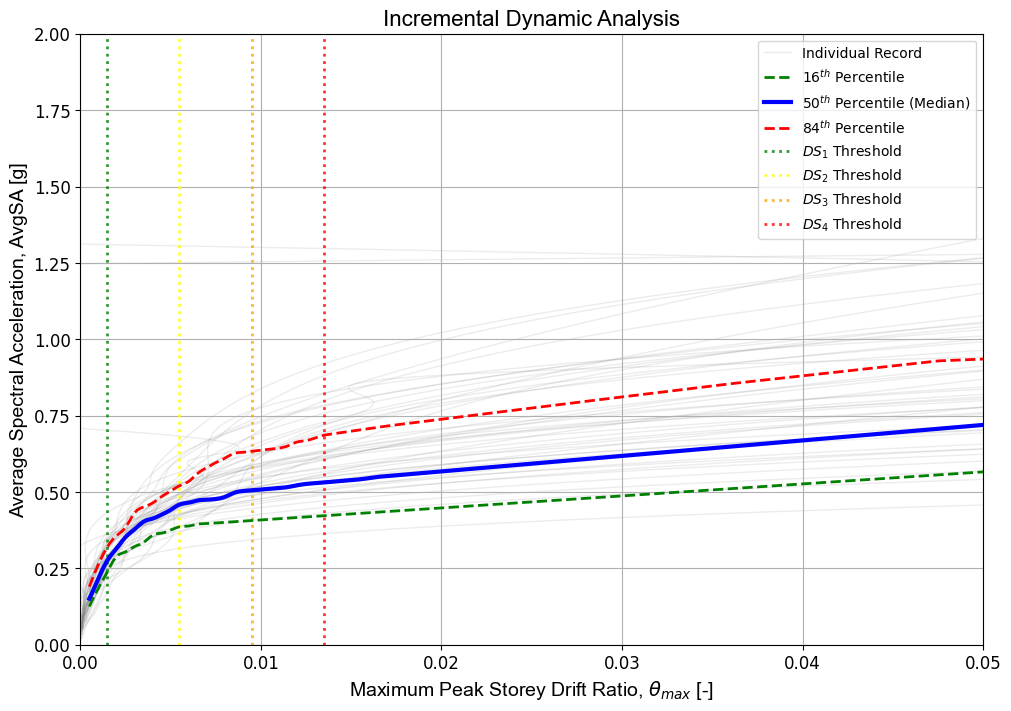

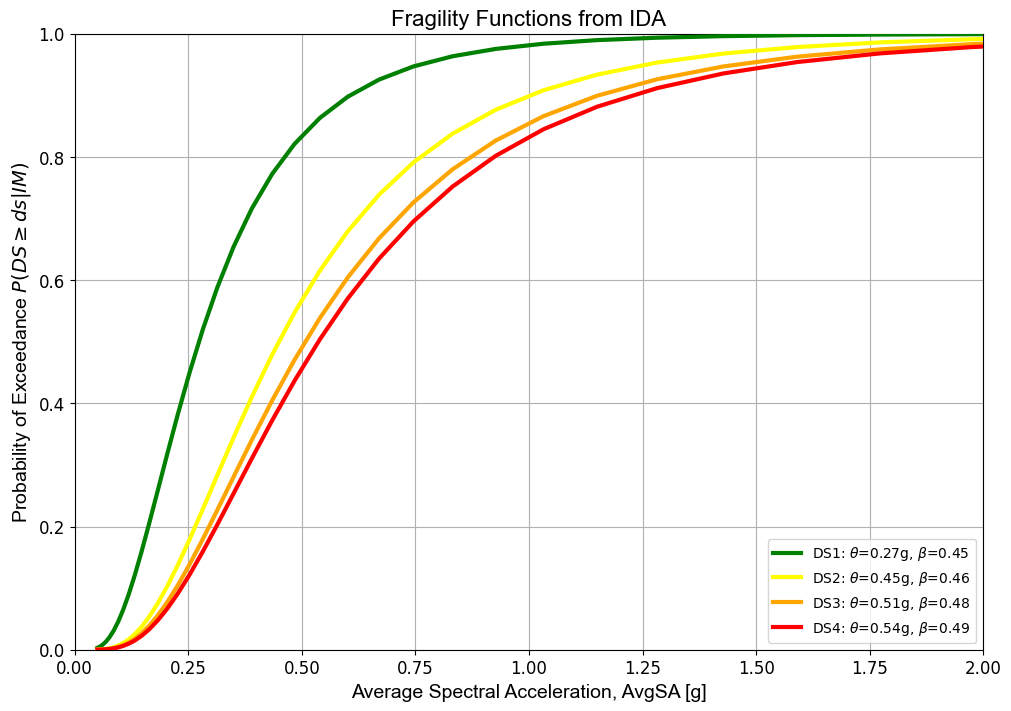

In [14]:
# Initialise the plotter class
pl=plotter()

# Plot the IDA curves
pl.plot_ida_analysis(ida_dict,
                     imt_label   = 'Average Spectral Acceleration, AvgSA [g]',
                     edp_label   = r'Maximum Peak Storey Drift Ratio, $\theta_{max}$ [-]',
                     xlims       = [0, 0.05],
                     ylims       = [0, 2],
                     title       = 'Incremental Dynamic Analysis',
                     pFlag       = True,
                     export_path = 'out/figures/ida_curves.png')

# Plot the fragility functions
pl.plot_fragility_from_ida(ida_dict,
                           xlims = [0, 2],
                           ylims = [0, 1],
                           imt_label = 'Average Spectral Acceleration, AvgSA [g]',
                           title = 'Fragility Functions from IDA',
                           pFlag = True,
                           export_path = 'out/figures/fragility_curves.png')

## Post-Process Building-Level Vulnerability Functions based on Fragility Functions and Consequence Models ###

### Expected Loss Ratio (Mean Damage Ratio)

The vulnerability function expresses the expected loss ratio as a function of an intensity measure level (IM) and is obtained by convolving fragility functions with damage-to-loss ratios associated with each damage state.
Let $P(DS = ds_i \mid IM)$ denote the probability of the structure being in damage state $ds_i$ at a given intensity measure level $IM$, and let $\mu_{LR,i}$ be the mean loss ratio associated with that damage state. The expected loss ratio at intensity level $IM$, denoted as $E[LR \mid IM]$, is defined as

$$
E[LR \mid IM] = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM),\mu_{LR,i}
$$

where:

* $N_{DS}$ is the total number of discrete damage states
* $P(DS = ds_i \mid IM)$ is derived from the fragility functions
* $\mu_{LR,i}$ is the mean loss ratio associated with damage state $ds_i$


#### Step 1: Calculate Damage-State Probabilities (i.e., Probabilities of Occurrence) from Fragility Functions

Fragility functions are commonly expressed in terms of probabilities of exceedance. The probability of being in a specific damage state is computed as

$$
P(DS = ds_i \mid IM) =
\begin{cases}
P(DS \ge ds_i \mid IM) - P(DS \ge ds_{i+1} \mid IM), & i < N_{DS} \
P(DS \ge ds_{N_{DS}} \mid IM), & i = N_{DS}
\end{cases}
$$

Assuming lognormal fragility functions, the probability of exceeding damage state $ds_i$ is given by

$$
P(DS \ge ds_i \mid IM) = 
\Phi\left(
\frac{\ln(IM) - \ln(\mu_{ds_i})}
{\beta_{ds_i}^{\text{total}}}
\right)
$$

where:

* $\mu_{ds_i}$ is the median intensity measure corresponding to damage state $ds_i$
* $\beta_{ds_i}^{\text{total}}$ is the total logarithmic standard deviation
* $\Phi(\cdot)$ is the standard normal cumulative distribution function

The total dispersion is computed as

$$
\beta_{ds_i}^{\text{total}} = 
\sqrt{
\beta_{\text{record-to-record}}^2
+
\beta_{\text{building-to-building}}^2
+
\beta_{\text{DS}}^2
}
$$

where:

* $\beta_{\text{record-to-record}}$ (or $\beta_{\text{EDP}\mid IM}$) represents ground-motion variability
* $\beta_{\text{building-to-building}}$ (or $\beta_{\text{MDL}}$) captures model and structural variability
* $\beta_{\text{DS}}$ represents uncertainty in damage-state definition and thresholds


#### Step 2: Calculation of Uncertainty in Expected Loss

#### Method 1: Silva [5] (Semi-Empirical)

When uncertainty in the damage-to-loss relationship is not explicitly modelled, the dispersion of the loss ratio conditional on the intensity measure can be estimated using the empirical formulation proposed by Silva [5].
The coefficient of variation of the loss ratio conditional on $IM$ is defined as

$$
\mathrm{COV}(LR \mid IM) = 
\frac{\sigma_{LR \mid IM}}{E[LR \mid IM]}
$$

Following Silva [5], the standard deviation of the loss ratio is expressed as a function of the mean loss ratio:

$$
\sigma_{LR \mid IM} = 
0.5
\sqrt{
\overline{LR}_{\mid IM}
\left(
-0.7
* 2,\overline{LR}_{\mid IM}
- \sqrt{6.8,\overline{LR}_{\mid IM} + 0.5}
  \right)
  }
$$

where $\overline{LR}_{\mid IM}$ denotes the mean loss ratio conditional on the intensity measure level. This approach provides a conservative envelope for loss uncertainty and is commonly adopted when detailed loss information is unavailable.


#### Method 2: Explicit Statistical Propagation

Alternatively, the uncertainty in the expected loss ratio can be quantified by explicitly propagating uncertainty through the convolution of damage-state probabilities and damage-to-loss ratios. In this formulation, fragility functions account for uncertainty in structural response and damage-state thresholds, while additional uncertainty arises from variability in the damage-to-loss ratios associated with each damage state. The expected loss ratio conditional on $IM$ is given by

$$
E[LR \mid IM] = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM),\mu_{LR,i}
$$

Assuming the loss ratio conditional on each damage state is an independent random variable with coefficient of variation $\mathrm{COV}_{LR,i}$, the variance of the loss ratio conditional on $IM$ is computed using the **law of total variance**:

$$
\mathrm{Var}(LR \mid IM) = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM)
\left[
\sigma_{LR,i}^2
+
\left(
\mu_{LR,i} - E[LR \mid IM]
\right)^2
\right]
$$

where

$$
\sigma_{LR,i} =
\mathrm{COV}*{LR,i},\mu*{LR,i}
$$

The coefficient of variation of the loss ratio conditional on the intensity measure is then computed as

$$
\mathrm{COV}(LR \mid IM) = 
\frac{
\sqrt{\mathrm{Var}(LR \mid IM)}
}{
E[LR \mid IM]
}
$$

This formulation captures both:

* uncertainty **within damage states** due to variability in damage-to-loss ratios, and
* uncertainty due to **damage-state mixing** as intensity varies.


### Note on Beta-Distribution Interpretation of the Vulnerability Function

The loss ratio conditional on intensity measure level $IM$ is assumed to follow a **Beta distribution** as one option in the OpenQuake Engine <dist='BT'> (https://docs.openquake.org/oq-engine/3.23/manual/user-guide/inputs/vulnerability-models-inputs.html), owing to its bounded support on the interval $[0,1]$ and its flexibility in representing skewed distributions.

$$
LR \mid IM \sim \mathrm{Beta}(\alpha(IM), \beta(IM))
$$

The Beta distribution parameters are obtained by matching the first two moments:

$$
\mu(IM) = E[LR \mid IM]
$$

$$
\sigma^2(IM) = \mathrm{Var}(LR \mid IM)
$$

Defining the precision parameter

$$
\kappa(IM) = \alpha(IM) + \beta(IM)
$$

the Beta parameters are computed as

$$
\kappa(IM) =
\frac{\mu(IM),[1-\mu(IM)]}{\sigma^2(IM)} - 1
$$

$$
\alpha(IM) = \mu(IM),\kappa(IM),
\qquad
\beta(IM) = [1-\mu(IM)],\kappa(IM)
$$

This assumption enables a complete probabilistic characterization of loss conditional on intensity measure level and is particularly suitable for risk calculations, loss aggregation, and Monte Carlo simulation within performance-based engineering frameworks.

In [15]:
# Define consequence model to relate structural damage to a decision variable (i.e., expected loss ratio) 
consequence_model = [0.05, 0.20, 0.60, 1.00] # damage-to-loss ratios

# Define the uncertainty associated with each damage-to-loss ratio via coefficients of variation
consequence_cov = [0.30, 0.25, 0.20, 0.00] 

# Calculate the structural vulnerability function (using the explicit method)
structural_vulnerability_explicit_cov = pp.calculate_vulnerability_function(ida_dict['fragility']['poes'][:,:4],  # Use the poes output (columns 1 to 4 > DS1 to DS4)
                                                                            consequence_model,                      # The consequence model representing the normalised loss ratios per damage state
                                                                            cov_consequence = consequence_cov,      # The coefficient of variation model representing the uncertainty around the loss ratios per damage state
                                                                            uncertainty=True,                       # Set uncertainty equal to True to calculate COV of the Beta Distribution
                                                                            method='explicit')                      # Set method to explicit for COV calculation per law of total variance         

# Calculate the structural vulnerability function (using the explicit method)
structural_vulnerability_silva_cov = pp.calculate_vulnerability_function(ida_dict['fragility']['poes'][:,:4],  # Use the poes output (columns 1 to 4 > DS1 to DS4)
                                                                         consequence_model,                      # The consequence model representing the normalised loss ratios per damage state
                                                                         uncertainty=True,                       # Set uncertainty equal to True to calculate COV of the Beta Distribution
                                                                         method='silva')                         # Set method to Silva for semi-empirical COV calculation     

## Plot the Vulnerability Functions with Uncertainty Visualisation ##

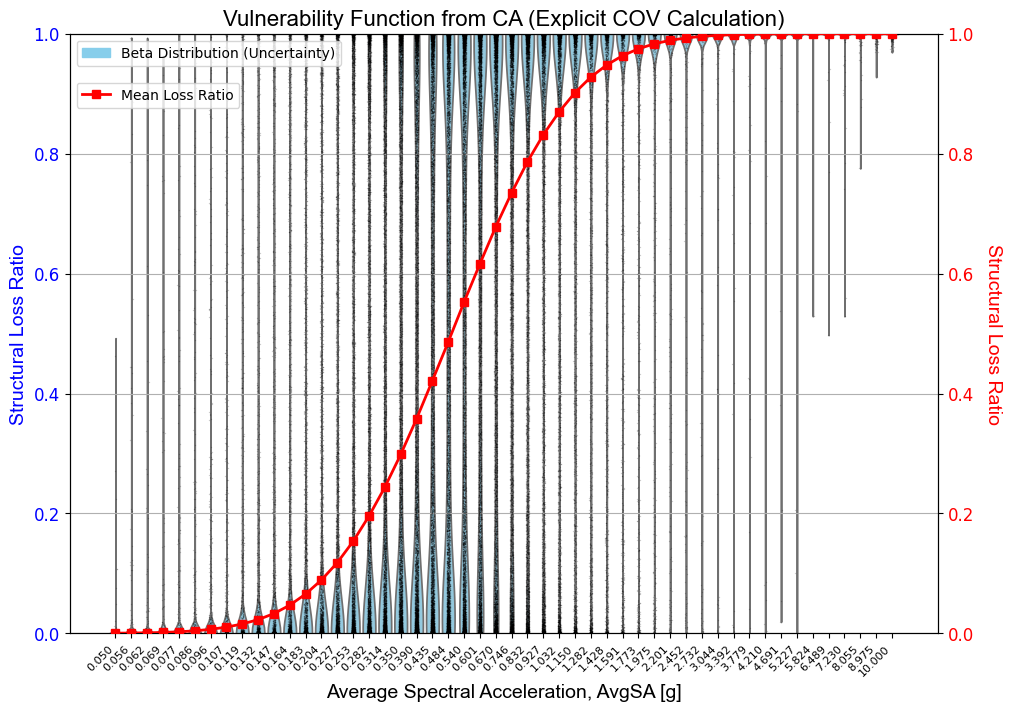

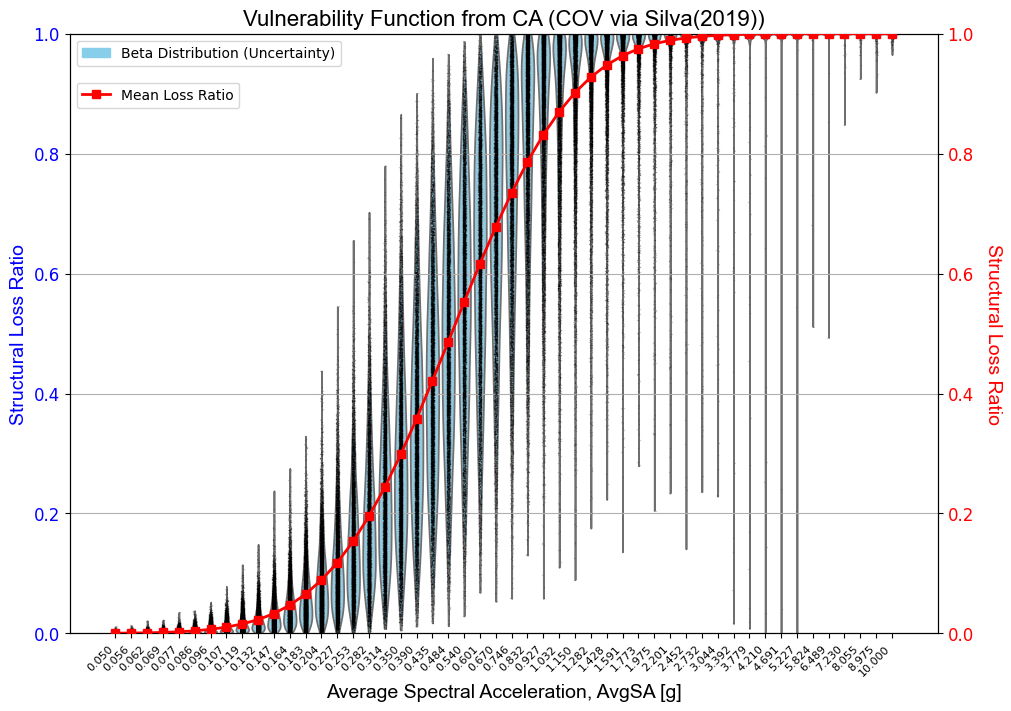

In [16]:
# Plot the structural vulnerability function from the explicit COV method
pl.plot_vulnerability_function(structural_vulnerability_explicit_cov['IML'],
                               structural_vulnerability_explicit_cov['Loss'],
                               structural_vulnerability_explicit_cov['COV'],
                               imt_label   = 'Average Spectral Acceleration, AvgSA [g]',
                               loss_label  = 'Structural Loss Ratio',
                               title       = 'Vulnerability Function from CA (Explicit COV Calculation)',
                               pFlag       = True,
                               export_path = 'out/figures/vulnerability_curve_explicit_cov.png')

# Plot the structural vulnerability function from the 'Silva (2019)' method
pl.plot_vulnerability_function(structural_vulnerability_silva_cov['IML'],
                               structural_vulnerability_silva_cov['Loss'],
                               structural_vulnerability_silva_cov['COV'],
                               imt_label   = 'Average Spectral Acceleration, AvgSA [g]',
                               loss_label  = 'Structural Loss Ratio',
                               title       = 'Vulnerability Function from CA (COV via Silva(2019))',
                               pFlag       = True,
                               export_path = 'out/figures/vulnerability_curve_silva_cov.png')